In [1]:
#true randomness
import numpy as np
from scipy.stats import chisquare

def frequency_test(data):
    values, counts = np.unique(data, return_counts=True)
    expected = np.full_like(counts, len(data) / len(values))
    chi2, p = chisquare(counts, f_exp=expected)
    return chi2, p

def runs_test(data):
    n1 = np.sum(data)
    n2 = len(data) - n1
    runs = 1
    for i in range(1, len(data)):
        if data[i] != data[i-1]:
            runs += 1
    expected_runs = ((2*n1*n2)/(n1+n2)) + 1
    variance_runs = (2*n1*n2*(2*n1*n2 - n1 - n2)) / (((n1+n2)**2)*(n1+n2-1))
    z = (runs - expected_runs) / np.sqrt(variance_runs)
    return runs, z

def autocorrelation_test(data, lag=1):
    data = np.array(data)
    n = len(data)
    if n <= lag:
        return None
    autocorr = np.corrcoef(data[:-lag], data[lag:])[0,1]
    return autocorr

if __name__ == "__main__":
    #voorbeelddata
    data = np.random.randint(0, 2, 1000)
    
    chi2, p = frequency_test(data)
    print(f"Frequency Test: chi2={chi2:.2f}, p-value={p:.4f}")
    
    runs, z = runs_test(data)
    print(f"Runs Test: runs={runs}, z={z:.2f}")
    
    autocorr = autocorrelation_test(data, lag=1)
    print(f"Autocorrelation (lag=1): {autocorr:.4f}")

Frequency Test: chi2=0.10, p-value=0.7518
Runs Test: runs=469, z=-2.02
Autocorrelation (lag=1): 0.0629


Random bitstream
RANDOMNESS TEST RESULTS
Shannon Entropy          : 1.0000
Monobit Test             : 0.9950
Runs Test                : 0.9946
Autocorrelation Test     : 0.9947
Serial Test              : 0.8540
Overall Randomness Score  : 96.77%
good random

Visualisaties opgeslagen als 'random_test.png'


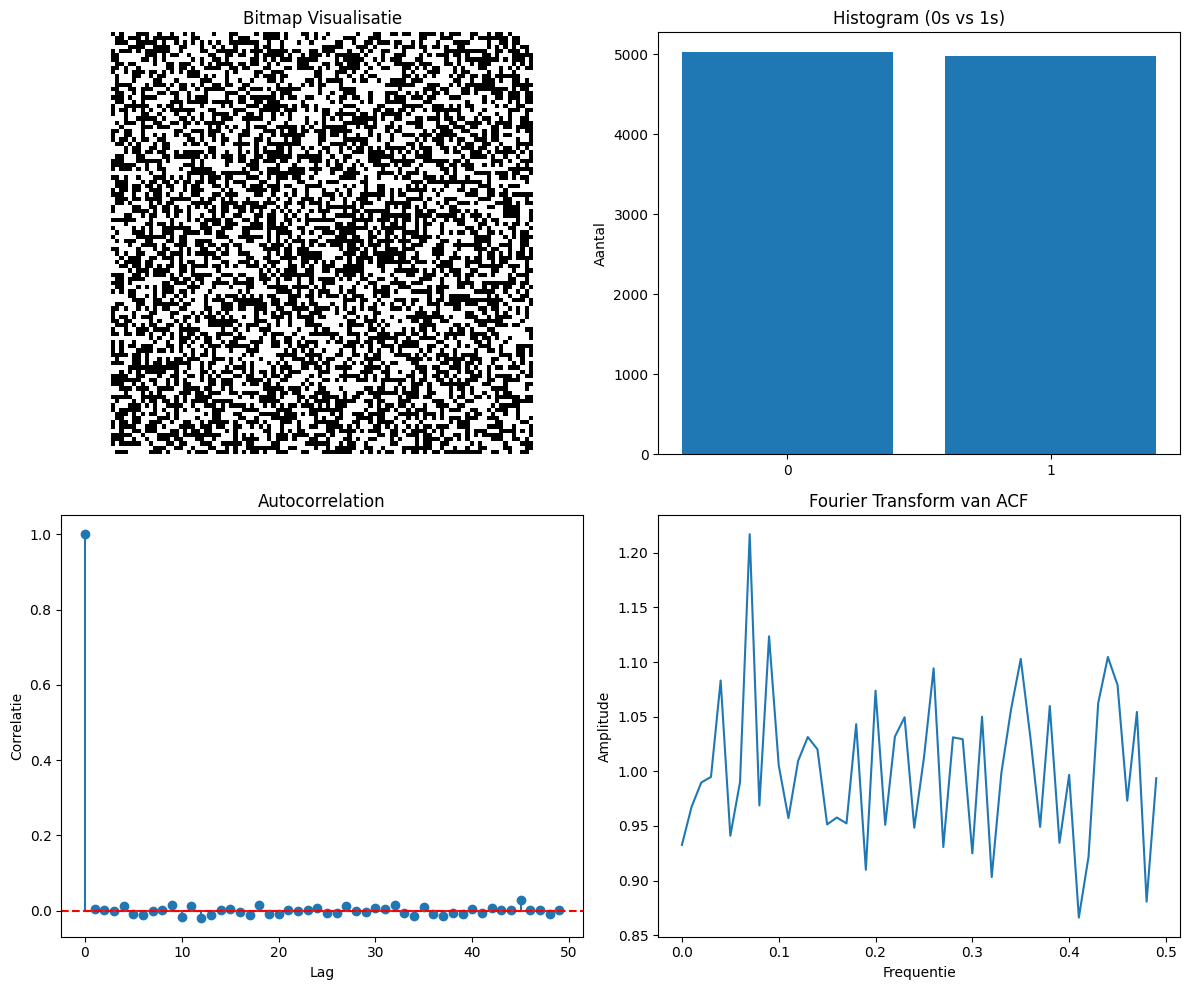

TEST 2: not-random bitstream (changing)
RANDOMNESS TEST RESULTS
Shannon Entropy          : 1.0000
Monobit Test             : 1.0000
Runs Test                : 0.0004
Autocorrelation Test     : 0.0001
Serial Test              : 0.0000
Overall Randomness Score  : 40.01%
bad random



In [2]:
import numpy as np
from scipy import stats
from collections import Counter
import matplotlib.pyplot as plt

def test_randomness(bitstream):
    #numpy array
    if isinstance(bitstream, str):
        bits = np.array([int(b) for b in bitstream])
    else:
        bits = np.array(bitstream)
    
    n = len(bits)
    results = {}
    
    #shannon entropy
    ones = np.sum(bits)
    zeros = n - ones
    p0 = zeros / n if zeros > 0 else 0
    p1 = ones / n if ones > 0 else 0
    
    if p0 > 0 and p1 > 0:
        entropy = -(p0 * np.log2(p0) + p1 * np.log2(p1))
    else:
        entropy = 0
    
    results['Shannon Entropy'] = entropy
    
    #monobit test
    expected = n / 2
    monobit_score = 1 - abs(ones - expected) / expected
    monobit_score = max(0, monobit_score)  #no negative
    
    results['Monobit Test'] = monobit_score
    
    #run
    runs = 1
    for i in range(1, n):
        if bits[i] != bits[i-1]:
            runs += 1
    
    #expected runs
    expected_runs = ((2 * ones * zeros) / n) + 1

    if expected_runs > 0:
        runs_score = 1 - abs(runs - expected_runs) / expected_runs
        runs_score = max(0, runs_score)
    else:
        runs_score = 0
    
    results['Runs Test'] = runs_score
    
    #autocorrelation test
    if n > 1:
        mean = np.mean(bits)
        autocorr = np.correlate(bits - mean, bits - mean, mode='full')
        autocorr = autocorr[n-1:] / autocorr[n-1] 
        
        #first lag
        if len(autocorr) > 1:
            autocorr_score = 1 - abs(autocorr[1])
            autocorr_score = max(0, autocorr_score)
        else:
            autocorr_score = 1
    else:
        autocorr_score = 0
    
    results['Autocorrelation Test'] = autocorr_score
    
    #serial test
    pairs = []
    for i in range(n-1):
        pair = str(bits[i]) + str(bits[i+1])
        pairs.append(pair)
    
    pair_counts = Counter(pairs)
    expected_pair = (n-1) / 4
    
    chi_square = sum((count - expected_pair)**2 / expected_pair 
                     for count in pair_counts.values())
    
    #calculate p-value
    p_value = 1 - stats.chi2.cdf(chi_square, df=3)
    serial_score = p_value  #p-value > 0.05 is good
    
    results['Serial Test'] = serial_score
    
    #overall score
    overall_score = np.mean(list(results.values())) * 100
    return results, overall_score

def print_results(results, overall_score):
    print("RANDOMNESS TEST RESULTS")
    
    for test_name, score in results.items():
        print(f"{test_name:25s}: {score:.4f}")
    
    print(f"Overall Randomness Score  : {overall_score:.2f}%")
    
    # Interpretatie
    if overall_score >= 95:
        print("good random")
    elif overall_score >= 85:
        print("decent random")
    elif overall_score >= 70:
        print("not good random")
    else:
        print("bad random")
    print()

def visualize_bitstream(bitstream, filename='randomness_plots.png'):
    if isinstance(bitstream, str):
        bits = np.array([int(b) for b in bitstream])
    else:
        bits = np.array(bitstream)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    #bitmap
    size = int(np.sqrt(len(bits)))
    bitmap = bits[:size*size].reshape(size, size)
    axes[0, 0].imshow(bitmap, cmap='binary')
    axes[0, 0].set_title('Bitmap Visualisatie')
    axes[0, 0].axis('off')
    
    #histogram
    axes[0, 1].bar(['0', '1'], [np.sum(bits==0), np.sum(bits==1)])
    axes[0, 1].set_title('Histogram (0s vs 1s)')
    axes[0, 1].set_ylabel('Aantal')
     #autocorrelation
    mean = np.mean(bits)
    autocorr = np.correlate(bits - mean, bits - mean, mode='full')
    autocorr = autocorr[len(bits)-1:] / autocorr[len(bits)-1]
    lags = range(min(50, len(autocorr)))
    axes[1, 0].stem(lags, autocorr[:len(lags)])
    axes[1, 0].set_title('Autocorrelation')
    axes[1, 0].set_xlabel('Lag')
    axes[1, 0].set_ylabel('Correlatie')
    axes[1, 0].axhline(y=0, color='r', linestyle='--')
    
    #fourier transform
    fft = np.fft.fft(autocorr[:min(100, len(autocorr))])
    freq = np.fft.fftfreq(len(fft))
    axes[1, 1].plot(freq[:len(freq)//2], np.abs(fft[:len(fft)//2]))
    axes[1, 1].set_title('Fourier Transform van ACF')
    axes[1, 1].set_xlabel('Frequentie')
    axes[1, 1].set_ylabel('Amplitude')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    print(f"Visualisaties opgeslagen als '{filename}'")
    plt.show()

#example
if __name__ == "__main__":
    #bitstream 
    print("Random bitstream")
    random_bits = ''.join([str(np.random.randint(0, 2)) for _ in range(10000)])
    results1, score1 = test_randomness(random_bits)
    print_results(results1, score1)
    visualize_bitstream(random_bits, 'random_test.png')
    
    #not random bitstream
    print("TEST 2: not-random bitstream (changing)")
    non_random_bits = '01' * 5000
    results2, score2 = test_randomness(non_random_bits)
    print_results(results2, score2)
    # FOR YOUR OWN TRNG DATA: Comment out the examples above (with #)
    # and remove the # below to test your own file
    
    # with open('jouw_trng_bestand.txt', 'r') as f:  #name file
    #     my_bitstream = f.read().strip()
    # 
    # results, score = test_randomness(my_bitstream)
    # print_results(results, score)
    # visualize_bitstream(my_bitstream, 'mijn_trng_test.png')  #output name